In [1]:
# LIBRARIES
from datetime import timedelta
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from prophet import Prophet

C:\Users\jha95\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [13]:
# FUNCTIONS
def get_api_data(
    url:str,
    params:dict):
    """
    """
    ## Respuesta de la API
    response = requests.get(url, params=params)
    # Validación de la respuesta de la API obtenida
    if response.status_code == 200:
        # Convierte la respuesta en JSON
        data = response.json()
        # Crea un Dataframe de pandas con esta respuesta
        df = pd.DataFrame(data)
        # Selección de columnas y tipado
        df = df[["serie", "descripcion", "descripcionCorta", "fechas", "valores"]]
        df = df.explode(["fechas", "valores"])
        df["fechas"] = pd.to_datetime(df["fechas"]).dt.date
        df["tipo_valores"] = "Valor Real"
        df = df.sort_values("fechas")
        df = df.reset_index(drop=True)
        return df
    else:
        print("Error al obtener los datos: ", response.status_code)


def make_predictions(
        df:pd.DataFrame,
        train_treshold:float):
    """
    """
    # Ajustes en el dataframe original
    serie_value = df["serie"].unique()[0]
    descripcion_value = df["descripcion"].unique()[0]
    descripcionCorta_value = df["descripcionCorta"].unique()[0]
    df_prophet = df[["fechas", "valores"]]
    df_prophet.columns = ["ds", "y"]
    # Modelo de predicción
    train_split = int(len(df_prophet) * train_treshold)
    df_train = df_prophet[0:train_split]
    df_test = df_prophet[train_split:]
    model = Prophet()
    model.fit(df_prophet)
    future = model.make_future_dataframe(periods=5, freq='QE')
    forecast = model.predict(future)
    forecast = forecast[["ds", "yhat"]]
    r2_error = r2_score(df_test["y"], forecast["yhat"].tail(len(df_test)))
    mae_error = mean_absolute_error(df_test["y"], forecast["yhat"].tail(len(df_test)))
    # Ajustes en los resultados
    forecast.columns = ["fechas", "valores"]
    forecast["fechas"] = pd.to_datetime(forecast["fechas"]).dt.date
    forecast["serie"] = serie_value
    forecast["descripcion"] = descripcion_value
    forecast["descripcionCorta"] = descripcionCorta_value
    forecast["tipo_valores"] = "Predicción"
    return forecast, r2_error, mae_error


In [14]:
# GLOBALS
url = f"https://app.bde.es/bierest/resources/srdatosapp/listaSeries"
params = {
    "idioma": "es",
    "series": "D_BFDAD045",
    # "series": "D_BFDAD045,D_BFDA3040,D_BFDAD027,D_BFDA3037",
    "rango": "MAX"
}

In [ ]:
# MAIN
df = get_api_data(url=url, params=params)

In [ ]:
with pd.option_context('display.max_colwidth', None):
    display(df)

,serie,descripcion,descripcionCorta,fechas,valores,tipo_valores
0,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,1986-07-01,74363,Valor Real
1,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,1986-10-01,85831,Valor Real
2,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,1987-01-01,80403,Valor Real
3,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,1987-04-01,74021,Valor Real
4,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,1987-07-01,80193,Valor Real
...,...,...,...,...,...,...
150,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,2024-01-01,2346377,Valor Real
151,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,2024-04-01,2455639,Valor Real
152,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,2024-07-01,2557030,Valor Real
153,D_BFDAD045,ENTIDADES DE DEPOSITO DEPOSITOS DEL SECTOR PUBLICO DISTRIBUCION PROVINCIAL TENERIFE,ED. Depósitos. De AAPP. Tenerife,2024-10-01,2750245,Valor Real


In [16]:
train_treshold = 0.75
df_final = pd.DataFrame(columns=["serie", "descripcion", "descripcionCorta", "fechas", "valores", "tipo_valores"])
for serie in df["serie"].drop_duplicates():
    df_iteration = df[df["serie"]==serie].copy()
    df_pred, r2_error, mae_error = make_predictions(df_iteration, train_treshold)
    print(f"Serie: {serie}. R2: {r2_error}, MAE: {mae_error}")
    df_final = pd.concat([df_final, df_iteration, df_pred])

11:31:23 - cmdstanpy - INFO - Chain [1] start processing
11:31:23 - cmdstanpy - INFO - Chain [1] done processing


Serie: D_BFDAD045. R2: 0.6906066710664203, MAE: 207196.92695567026


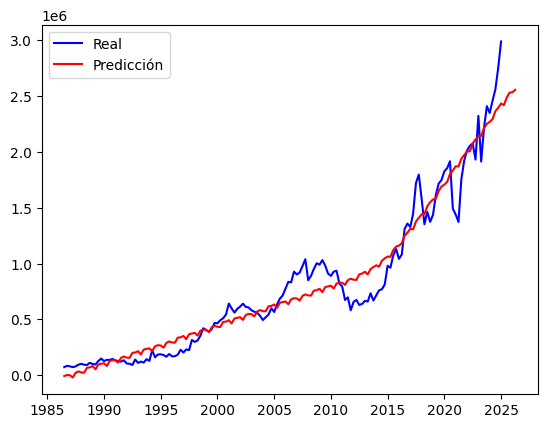

In [17]:
plt.plot(df_iteration["fechas"], df_iteration["valores"], label='Real', color='blue')
plt.plot(df_pred["fechas"], df_pred["valores"], label='Predicción',  color='red')
plt.legend()

In [ ]:
# df_final.to_csv(path_or_buf="./predicciones.csv", sep=",", header=True, index=False)